<span style="color: #177cff ; font-size: 40px;">Question 1: Applying CLT On Bernoulli Distribution</span>

<span style="color: gold; font-size: 30px;">Part 1: Plotting The Initial Binomial Distribution</span>

In this part I'll plot the pmf for X ~ Bin(270, 0.3) which is a binomial distribution. I'll use the np.scatter() function because the Binomial distribution is discrete and not continious to use plt.plot() function.

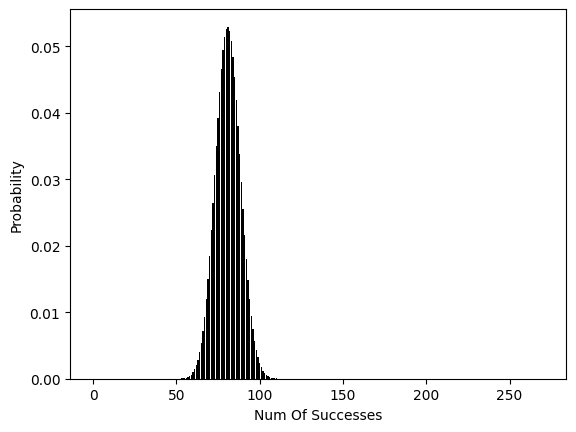

In [140]:
import numpy as np
import matplotlib.pyplot as plt
import math
n = 270
p = 0.3

x = range(0, n + 1)
y = list(map(lambda k: math.comb(n, k) * p ** k * (1-p) ** (n - k), x))

plt.bar(x, y, color='black')
plt.xlabel("Num Of Successes")
plt.ylabel("Probability")

plt.show()

<span style="color: gold; font-size: 30px;">Part 2: Normalizing The X Axis</span>

For this part we use the z-score normalization formula and normalize the x interval.

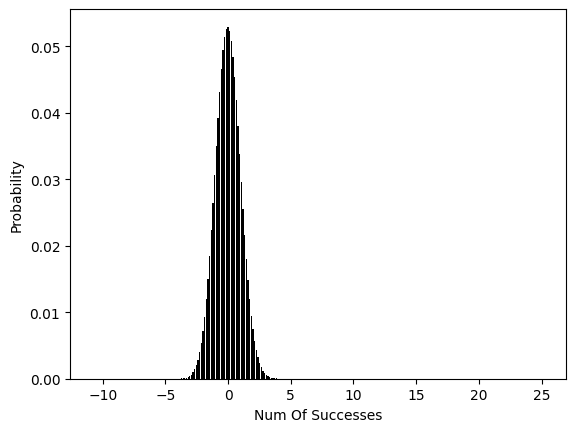

In [141]:
x_mean = n * p; x_std = (n * p * (1-p)) ** (1/2)
x_normalized = list(map(lambda k: (k - x_mean) / x_std, x))

plt.bar(x_normalized, y, color='black', width=0.1)
plt.xlabel("Num Of Successes")
plt.ylabel("Probability")

plt.show()


<span style="color: gold; font-size: 30px;">Part 3: Adding The Standard Normal Distribution To The Plot</span>

I'll use the scipy library to to use its already built pdf function for normal distribution.

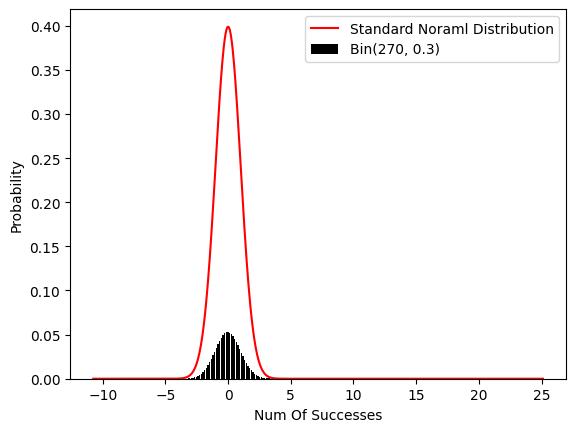

In [146]:
from scipy.stats.distributions import norm

plt.bar(x_normalized, y, color='black', width=0.1, label = "Bin(270, 0.3)")

x_ = np.linspace(min(x_normalized), max(x_normalized), num = 1000)
y_ = norm.pdf(x_, 0, 1)
plt.plot(x_, y_, color = "red", label = "Standard Noraml Distribution")

plt.xlabel("Num Of Successes")
plt.ylabel("Probability")
plt.legend()

plt.show()

As we can see, these two distributions are so similar and it looks like they are only different in a coefficient. This gives us some intuition about the CLT theorom. Because the Binomial distribution is sum of some Bernoulli distributed variables. 

<span style="color: gold; font-size: 30px;">Part 4: Sum Of Bars</span>

In [143]:
sum_of_bars = sum(y)
print(f"{sum_of_bars:.5f}")

1.00000


As we can see, the summation of the bar values in the pmf function for Bin(270, 0.3) is equal to 1. It is because the X random variable has to be in range of 0 to 270 and nothing else. But the noraml distribution diagram shows something else; it is a pdf function. It shows the probability density for our random variable not the probability itself. So actuall we can say each bar is an integral of that normal pdf in an interval of length 1. This justifies why the summation of all bars is equal to 1.

<span style="color: gold; font-size: 30px;">Part 5: Calculating And Imposing The Coefficient</span>

To calculate the coefficient of normal pdf to estimate the Binomial distribuion, we have to be able to take the integral of that function from -5 to +5 and reverse it. But we can't because that function is not integrable. So we use the Riemann calculations.



In [ ]:
N = 1000
a = 0
b = 270 
dx = (b - a) / N

riemann_sum = 0
for i in range(N):
    riemann_sum += norm.pdf(a, x_mean, x_std) * dx
    a += dx

print(f"As we expected, the sum of values for riemann integral is equal to: {riemann_sum:.2f}")

C = 1 / sum(norm.pdf(x_normalized, 0, 1))

print(C)
print(1 / x_std)

As we expected, the sum of values for riemann integral is equal to: 1.00
0.13280317881493256
0.13280317881493262


As we can see, balancing coefficient(denoted by C) is exactly equal to 1 / x_std. It means our coefficient is equal to reversed of standard deviation of the initial Binomial distributed random variable.

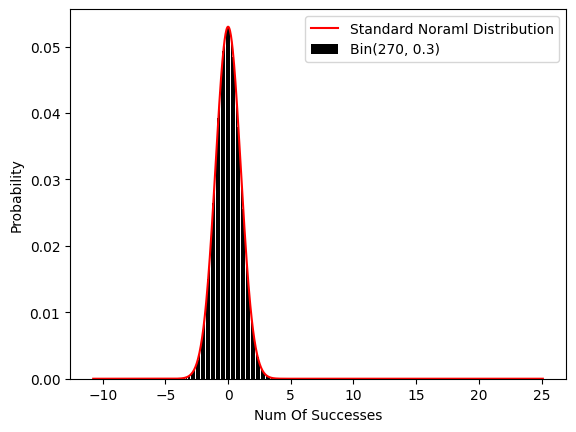

In [161]:
plt.bar(x_normalized, y, color='black', width=0.1, label = "Bin(270, 0.3)")

plt.plot(x_, C * y_, color = "red", label = "Standard Noraml Distribution")

plt.xlabel("Num Of Successes")
plt.ylabel("Probability")
plt.legend()

plt.show()

And here it is! A completely fit and satisfying estimation for the Binomial distribution. 

<span style="color: gold; font-size: 30px;">Part 6: Coin Flipping: Binomial And Normal Estimation</span>



In [157]:
p = 1/2
n = 100
k = 55
    
binom_mean = n * p
binom_std = (n * p * (1-p)) ** (1/2)

num_of_heads = np.arange(0, n + 1)
num_of_heads_normalized = (num_of_heads - binom_mean) / binom_std
print("Binomial Probability: ", math.comb(n, k) * p ** k * (1-p) ** (n - k))
print("Normal Estimated Probability: ", (1 / binom_std) * norm.pdf((k - binom_mean) / binom_std, 0, 1))

Binomial Probability:  0.048474296626430755
Normal Estimated Probability:  0.04839414490382868


As we can see, the probabilities are exactly equal and they only have a slight and ignorable difference.

<span style="color: gold; font-size: 30px;">Part 7: Probability Of k Being Between 40 and 60</span>

40 < k < 60 -> -2 < (k-50)/5 < 2

In [159]:
N = 1000
a = -2
b = 2
dx = (b - a) / N

probability = 0
for i in range(N):
    probability += norm.pdf(a, 0, 1) * dx
    a += dx
    
print(probability)

0.9544994481518967
